In [1]:
# code stolen from:
# https://github.com/keras-team/keras-io/blob/master/examples/structured_data/structured_data_classification_from_scratch.py

In [2]:
"""
## Setup
"""

import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers


In [3]:
"""
## Preparing the data
Let's download the data and load it into a Pandas dataframe:
"""

file_url = "http://storage.googleapis.com/download.tensorflow.org/data/heart.csv"
dataframe = pd.read_csv(file_url)


In [4]:
"""
The dataset includes 303 samples with 14 columns per sample (13 features, plus the target
label):
"""

dataframe.shape

(303, 14)

In [5]:
"""
Here's a preview of a few samples:
"""

dataframe.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


# wide & deep exploration

question                                               | completed
-------------------------------------------------------|------------
categorical vbls with unseen values in test set?       | no
wide & deep model?                                     | yes
embedded categorical variables                         | no
crossed categorical variables in dataset first         | no
normalize numeric variables in dataset first           | yes

In [6]:
experiment_data = dataframe[['target','slope','age','sex','thal','restecg']].copy()
experiment_data = experiment_data.query("thal.isin(['normal','reversible','fixed'])", engine='python')

experiment_data['sex'] = np.select( condlist = [ experiment_data['sex'] == 0,
                                                 experiment_data['sex'] == 1
                                               ],
                                    choicelist = [ 'female', 'male' ],
                                    default = None
                                  )

experiment_data['restecg'] = 'ecg' + experiment_data['restecg'].astype(str) 

experiment_data.sample(10)

,target,slope,age,sex,thal,restecg
189,0,1,49,female,normal,ecg0
0,0,3,63,male,fixed,ecg2
180,0,1,74,female,normal,ecg2
42,1,2,67,male,reversible,ecg0
57,0,1,47,male,normal,ecg2
49,0,2,48,male,normal,ecg2
245,1,2,57,male,reversible,ecg0
234,0,3,56,male,normal,ecg0
84,0,2,55,female,normal,ecg2
277,1,2,60,male,reversible,ecg2


In [7]:
# prepare features for model:

# normalize numeric variables:
experiment_data['slope'] = ( experiment_data['slope'] - np.mean(experiment_data['slope']) ) / np.std(experiment_data['slope'])  # normalize "slope" 
experiment_data['age'] = ( experiment_data['age'] - np.mean(experiment_data['age']) ) / np.std(experiment_data['age'])  # normalize "age" 

# create crossed features:
features_to_cross = ['sex','thal','restecg']
import itertools
for combination in itertools.combinations(features_to_cross,2):
    experiment_data[ combination[0]+'X'+combination[1] ] = experiment_data[ combination[0] ] + '_' + experiment_data[ combination[1] ]

experiment_data.sample(10)

,target,slope,age,sex,thal,restecg,sexXthal,sexXrestecg,thalXrestecg
220,0,-0.963983,0.490610,male,normal,ecg0,male_normal,male_ecg0,normal_ecg0
73,0,0.657016,1.155307,male,normal,ecg2,male_normal,male_ecg2,normal_ecg2
262,0,-0.963983,-1.503481,female,normal,ecg0,female_normal,female_ecg0,normal_ecg0
92,0,0.657016,1.044524,male,reversible,ecg0,male_reversible,male_ecg0,reversible_ecg0
129,1,0.657016,0.158261,female,reversible,ecg2,female_reversible,female_ecg2,reversible_ecg2
174,0,-0.963983,1.376872,female,normal,ecg0,female_normal,female_ecg0,normal_ecg0
267,0,0.657016,-0.063304,male,reversible,ecg2,male_reversible,male_ecg2,reversible_ecg2
243,0,0.657016,-1.060350,male,reversible,ecg0,male_reversible,male_ecg0,reversible_ecg0
232,1,0.657016,0.379827,female,fixed,ecg2,female_fixed,female_ecg2,fixed_ecg2
89,0,-0.963983,0.490610,male,normal,ecg0,male_normal,male_ecg0,normal_ecg0


In [8]:
# one hot encode the categorical variables:
experiment_data = pd.get_dummies( 
                experiment_data,
                columns = ['sex','thal','restecg','sexXthal','sexXrestecg','thalXrestecg']
              )

pd.set_option('display.max_columns', None)   # force pandas to print all columns
experiment_data.sample(10)

,target,slope,age,sex_female,sex_male,thal_fixed,thal_normal,thal_reversible,restecg_ecg0,restecg_ecg1,restecg_ecg2,sexXthal_female_fixed,sexXthal_female_normal,sexXthal_female_reversible,sexXthal_male_fixed,sexXthal_male_normal,sexXthal_male_reversible,sexXrestecg_female_ecg0,sexXrestecg_female_ecg1,sexXrestecg_female_ecg2,sexXrestecg_male_ecg0,sexXrestecg_male_ecg1,sexXrestecg_male_ecg2,thalXrestecg_fixed_ecg0,thalXrestecg_fixed_ecg1,thalXrestecg_fixed_ecg2,thalXrestecg_normal_ecg0,thalXrestecg_normal_ecg1,thalXrestecg_normal_ecg2,thalXrestecg_reversible_ecg0,thalXrestecg_reversible_ecg1,thalXrestecg_reversible_ecg2
177,0,0.657016,-0.284870,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0
43,0,0.657016,0.822958,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0
26,0,-0.963983,0.379827,1,0,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0
86,1,0.657016,0.822958,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
293,0,0.657016,0.269044,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1
175,1,0.657016,-0.063304,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
272,1,0.657016,-0.395653,1,0,0,0,1,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
178,1,0.657016,0.047478,1,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
68,0,-0.963983,0.379827,0,1,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
259,1,0.657016,-0.506436,0,1,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1


In [9]:
# train/validation 80%/20% split: 
val_data = experiment_data.sample(frac=0.2, random_state=1337)
train_data = experiment_data.drop(val_data.index)

print(
    "Using %d samples for training and %d for validation"
    % (len(train_data), len(val_data))
)

Using 241 samples for training and 60 for validation


In [10]:
def dataframe_to_dataset(dataframe):
    dataframe = dataframe.copy()
    labels = dataframe.pop("target")    # pull out y (response) column 
    ds = tf.data.Dataset.from_tensor_slices((dict(dataframe), labels))
    ds = ds.shuffle(buffer_size=len(dataframe))
    return ds

train_ds = dataframe_to_dataset(train_data)
val_ds = dataframe_to_dataset(val_data)

# batch the datasets:
train_ds = train_ds.batch(32)
val_ds = val_ds.batch(32)

In [11]:
all_inputs = []

for feature_j in experiment_data.columns:
    if feature_j != 'target':
        code_to_run = f"{feature_j} = keras.Input(shape=(1,), name='{feature_j}')"
        print(code_to_run)
        exec(code_to_run)
        code_to_run2 = f'all_inputs.append({feature_j})'
        print(code_to_run2)
        exec(code_to_run2)   

slope = keras.Input(shape=(1,), name='slope')
all_inputs.append(slope)
age = keras.Input(shape=(1,), name='age')
all_inputs.append(age)
sex_female = keras.Input(shape=(1,), name='sex_female')
all_inputs.append(sex_female)
sex_male = keras.Input(shape=(1,), name='sex_male')
all_inputs.append(sex_male)
thal_fixed = keras.Input(shape=(1,), name='thal_fixed')
all_inputs.append(thal_fixed)
thal_normal = keras.Input(shape=(1,), name='thal_normal')
all_inputs.append(thal_normal)
thal_reversible = keras.Input(shape=(1,), name='thal_reversible')
all_inputs.append(thal_reversible)
restecg_ecg0 = keras.Input(shape=(1,), name='restecg_ecg0')
all_inputs.append(restecg_ecg0)
restecg_ecg1 = keras.Input(shape=(1,), name='restecg_ecg1')
all_inputs.append(restecg_ecg1)
restecg_ecg2 = keras.Input(shape=(1,), name='restecg_ecg2')
all_inputs.append(restecg_ecg2)
sexXthal_female_fixed = keras.Input(shape=(1,), name='sexXthal_female_fixed')
all_inputs.append(sexXthal_female_fixed)
sexXthal_female_normal = ke

In [12]:
features_for_wide = layers.concatenate( 
    [ 
     sex_female, sex_male,
     thal_fixed, thal_normal, thal_reversible, 
     restecg_ecg0, restecg_ecg1, restecg_ecg2,
     sexXthal_female_fixed, sexXthal_female_normal, sexXthal_female_reversible, sexXthal_male_fixed, sexXthal_male_normal, sexXthal_male_reversible,
     sexXrestecg_female_ecg0, sexXrestecg_female_ecg1, sexXrestecg_female_ecg2, sexXrestecg_male_ecg0, sexXrestecg_male_ecg1, sexXrestecg_male_ecg2,
     thalXrestecg_fixed_ecg0, thalXrestecg_fixed_ecg1, thalXrestecg_fixed_ecg2, thalXrestecg_normal_ecg0, thalXrestecg_normal_ecg1, thalXrestecg_normal_ecg2,
     thalXrestecg_reversible_ecg0, thalXrestecg_reversible_ecg1,thalXrestecg_reversible_ecg2        
    ],
    name = 'inputs_for_wide'
)

features_for_deep = layers.concatenate( 
    [ 
        slope, 
        age,
    ],
    name = 'inputs_for_deep'
)

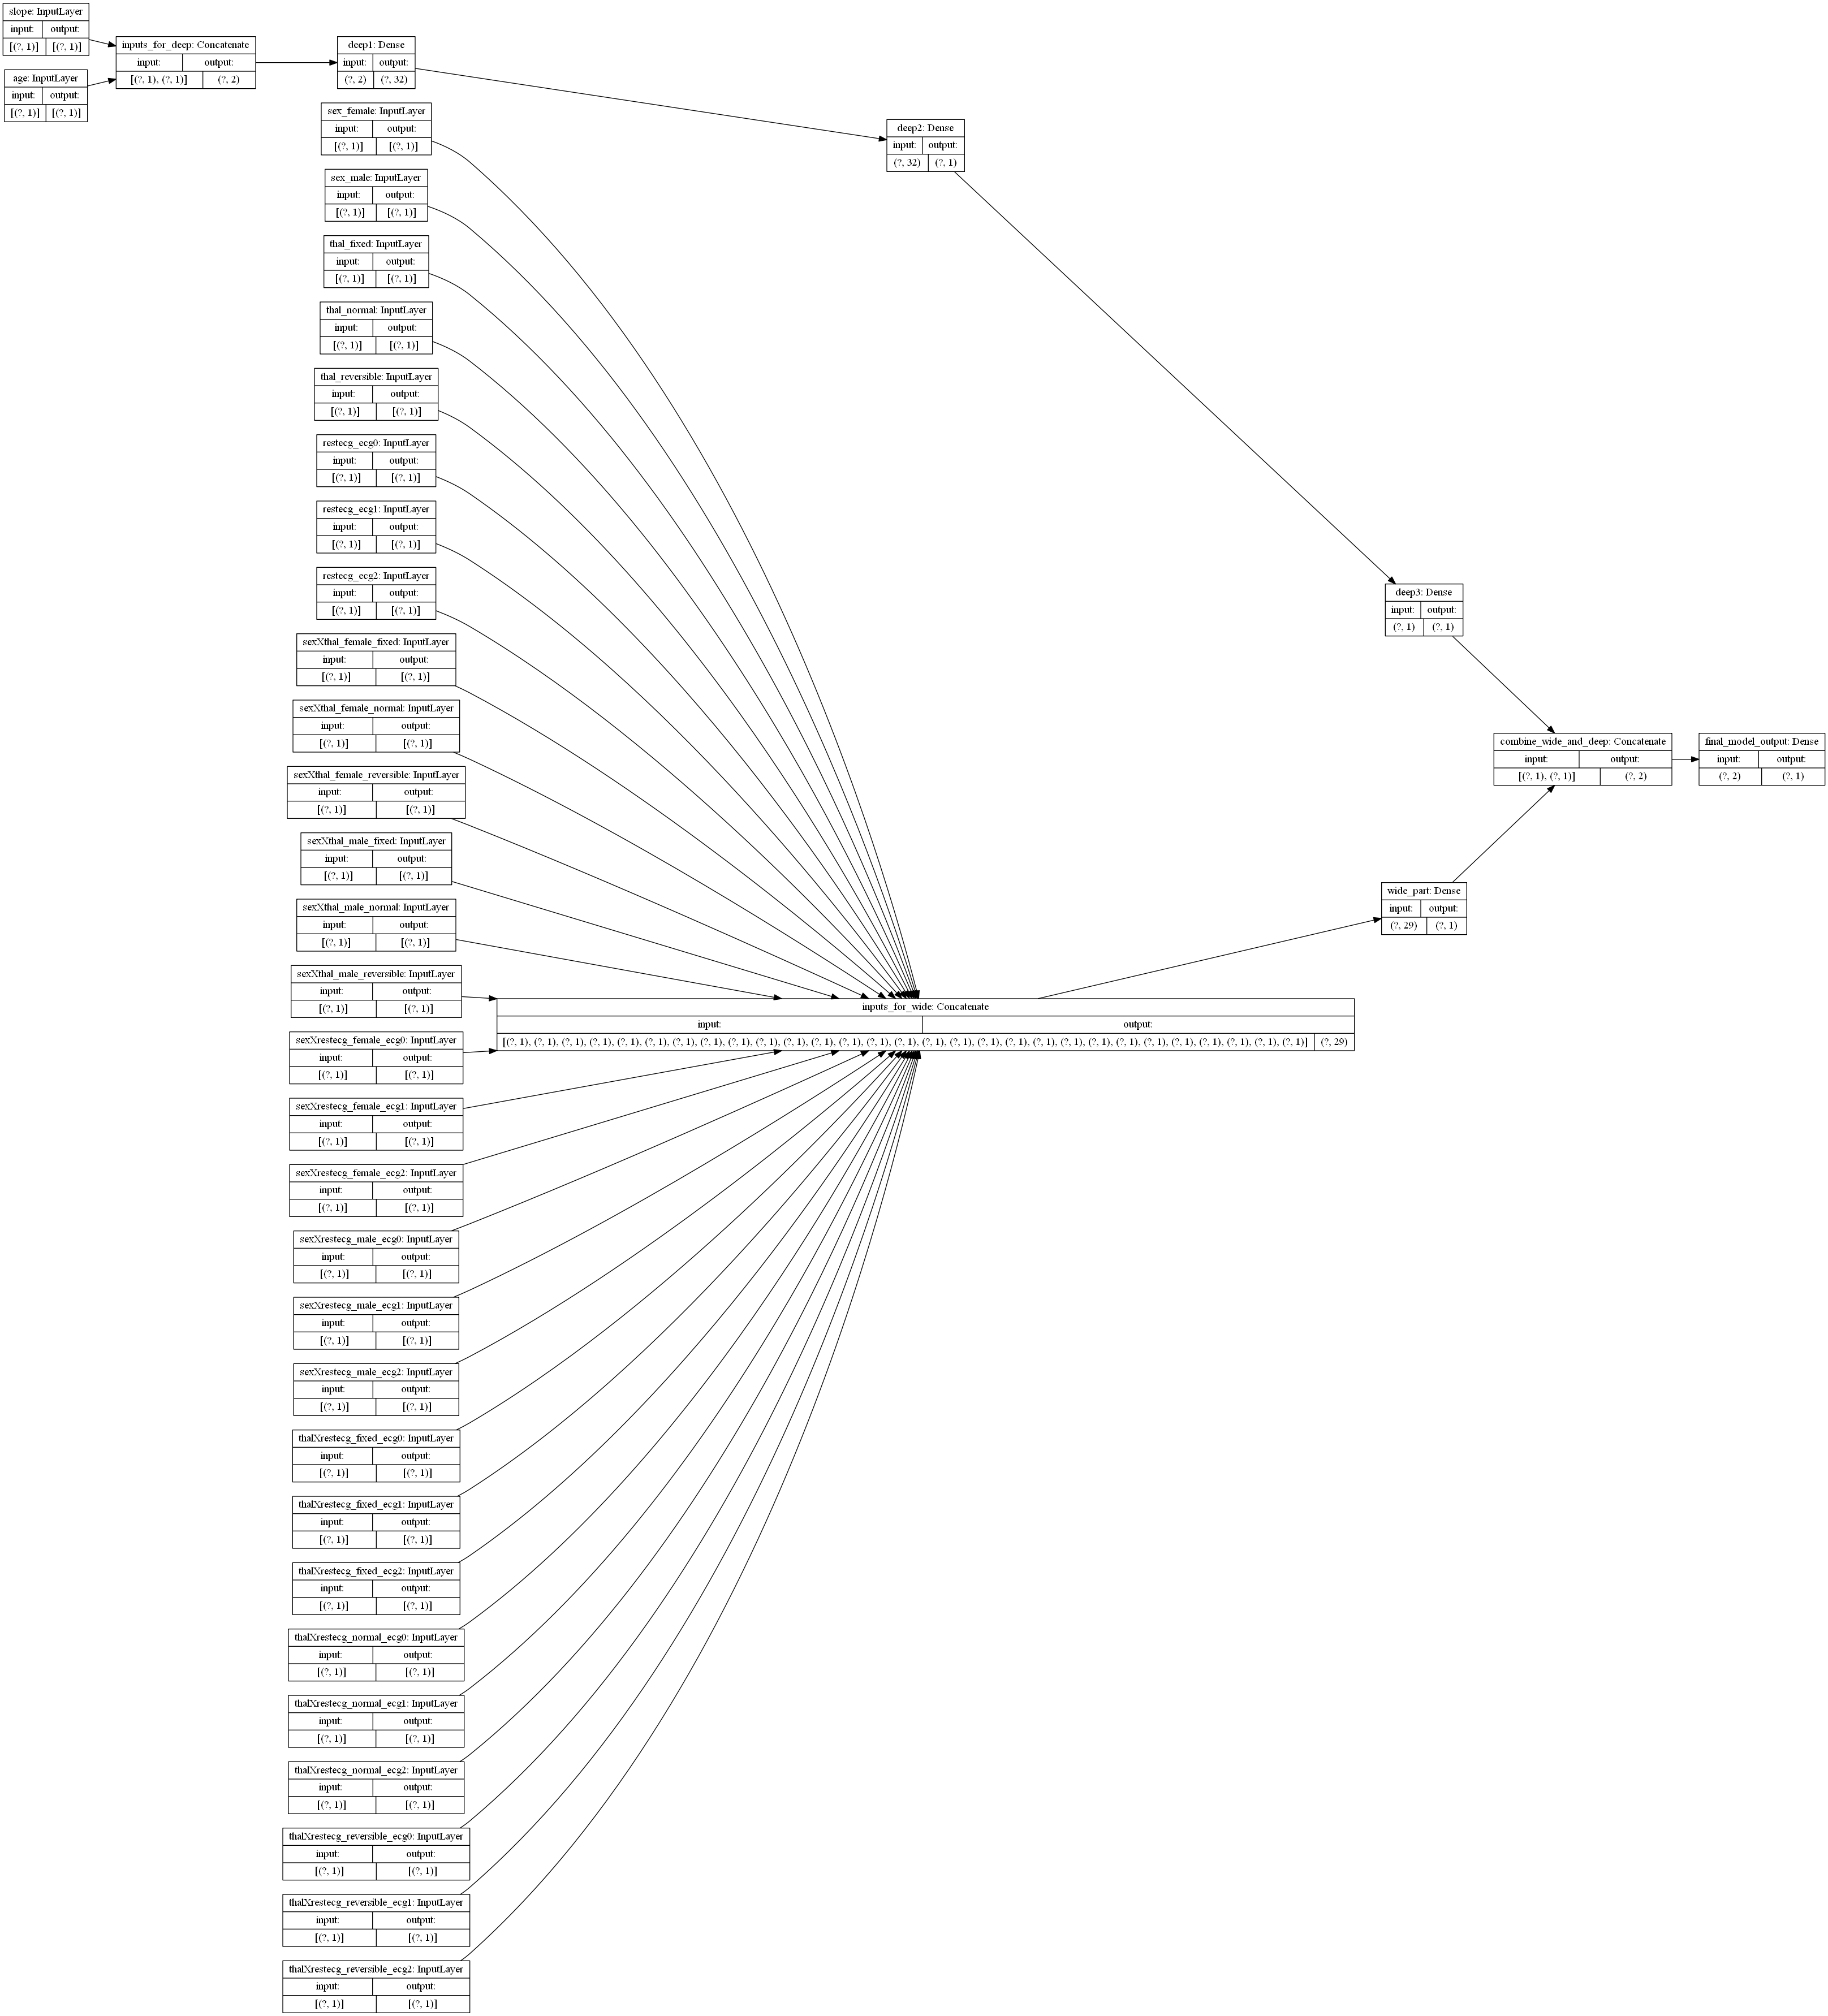

In [13]:
wide_output = layers.Dense(1, 
                           activation='sigmoid',
                           name = 'wide_part',
                          )(features_for_wide)

deep_layer1 = layers.Dense( 32, 
                            activation='relu',
                            name = 'deep1' 
                          )(features_for_deep)
deep_layer2 = layers.Dense( 1, 
                            activation='relu',
                            name = 'deep2'
                          )(deep_layer1)
deep_output = layers.Dense( 1, 
                            activation='sigmoid',
                            name = 'deep3'
                          )(deep_layer2)

combine_model_outputs = layers.concatenate( 
    [ 
        wide_output,
        deep_output,
    ],
    name = 'combine_wide_and_deep'
)

final_output = layers.Dense( 1, 
                             activation='sigmoid',
                             name = 'final_model_output'
                           )(combine_model_outputs)

model = keras.Model(all_inputs, final_output)
model.compile("adam", "binary_crossentropy", metrics=["accuracy"])

keras.utils.plot_model(model, show_shapes=True, rankdir="LR")

In [14]:
model.summary()

Model: "functional_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
slope (InputLayer)              [(None, 1)]          0                                            
__________________________________________________________________________________________________
age (InputLayer)                [(None, 1)]          0                                            
__________________________________________________________________________________________________
inputs_for_deep (Concatenate)   (None, 2)            0           slope[0][0]                      
                                                                 age[0][0]                        
__________________________________________________________________________________________________
sex_female (InputLayer)         [(None, 1)]          0                                 

In [15]:
model.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
8/8 [==============================] - 0s 21ms/step - loss: 0.7801 - accuracy: 0.2780 - val_loss: 0.7779 - val_accuracy: 0.2667
Epoch 2/50
8/8 [==============================] - 0s 4ms/step - loss: 0.7711 - accuracy: 0.2780 - val_loss: 0.7681 - val_accuracy: 0.2667
Epoch 3/50
8/8 [==============================] - 0s 5ms/step - loss: 0.7616 - accuracy: 0.2780 - val_loss: 0.7589 - val_accuracy: 0.2667
Epoch 4/50
8/8 [==============================] - 0s 4ms/step - loss: 0.7528 - accuracy: 0.2780 - val_loss: 0.7499 - val_accuracy: 0.2667
Epoch 5/50
8/8 [==============================] - 0s 5ms/step - loss: 0.7440 - accuracy: 0.2780 - val_loss: 0.7413 - val_accuracy: 0.2667
Epoch 6/50
8/8 [==============================] - 0s 5ms/step - loss: 0.7363 - accuracy: 0.2780 - val_loss: 0.7327 - val_accuracy: 0.2667
Epoch 7/50
8/8 [==============================] - 0s 4ms/step - loss: 0.7285 - accuracy: 0.2780 - val_loss: 0.7246 - val_accuracy: 0.2667
Epoch 8/50
8/8 [=================

In [16]:
# can extract the weights from model.layers:
model.layers